In [1]:
pip install pandas scikit-learn matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [11]:
data = pd.read_csv("anxiety_depression_data.csv")

print("Dataset Loaded Successfully ")
data.head()

Dataset Loaded Successfully 


,Age,Gender,Education_Level,Employment_Status,Sleep_Hours,Physical_Activity_Hrs,Social_Support_Score,Anxiety_Score,Depression_Score,Stress_Level,...,Chronic_Illnesses,Medication_Use,Therapy,Meditation,Substance_Use,Financial_Stress,Work_Stress,Self_Esteem_Score,Life_Satisfaction_Score,Loneliness_Score
0,56,Male,Bachelor's,Unemployed,6.0,0.4,3,4,2,9,...,0,NaN,0,1,NaN,4,3,7,5,1
1,69,Female,Bachelor's,Retired,8.8,2.8,6,18,7,6,...,0,NaN,1,0,NaN,1,4,7,4,6
2,46,Female,Master's,Employed,5.3,1.6,5,5,13,8,...,0,NaN,0,1,NaN,8,7,8,1,1
3,32,Female,High School,Unemployed,8.8,0.5,4,6,3,4,...,1,NaN,0,0,NaN,7,4,8,4,4
4,60,Female,Bachelor's,Retired,7.2,0.7,2,7,15,3,...,0,NaN,1,1,Frequent,8,9,5,7,7


In [12]:
print("Columns in dataset:")
print(data.columns)

Columns in dataset:
Index(['Age', 'Gender', 'Education_Level', 'Employment_Status', 'Sleep_Hours',
       'Physical_Activity_Hrs', 'Social_Support_Score', 'Anxiety_Score',
       'Depression_Score', 'Stress_Level', 'Family_History_Mental_Illness',
       'Chronic_Illnesses', 'Medication_Use', 'Therapy', 'Meditation',
       'Substance_Use', 'Financial_Stress', 'Work_Stress', 'Self_Esteem_Score',
       'Life_Satisfaction_Score', 'Loneliness_Score'],
      dtype='object')


In [13]:
anxiety_col = 'Anxiety_Score'
stress_col = 'Stress_Level'

def pain_level(row):
    if row[anxiety_col] > 7 and row[stress_col] > 7:
        return "High"
    elif row[anxiety_col] > 4:
        return "Medium"
    else:
        return "Low"

data['Pain_Level'] = data.apply(pain_level, axis=1)

data[['Anxiety_Score','Stress_Level','Pain_Level']].head()

,Anxiety_Score,Stress_Level,Pain_Level
0,4,9,Low
1,18,6,Medium
2,5,8,Medium
3,6,4,Medium
4,7,3,Medium


In [14]:
le = LabelEncoder()
data['Pain_Level'] = le.fit_transform(data['Pain_Level'])

print("Encoded Target Values:")
print(data['Pain_Level'].unique())

Encoded Target Values:
[1 2 0]


In [15]:
X = data.drop(['Pain_Level', 'Anxiety_Score', 'Stress_Level'], axis=1)
y = data['Pain_Level']

# Convert categorical → numeric
X = pd.get_dummies(X)

print("Features prepared ")

Features prepared 


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data Split Done ")

Data Split Done 


In [23]:
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

print("Model Trained Successfully ")

Model Trained Successfully 


In [25]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.6625


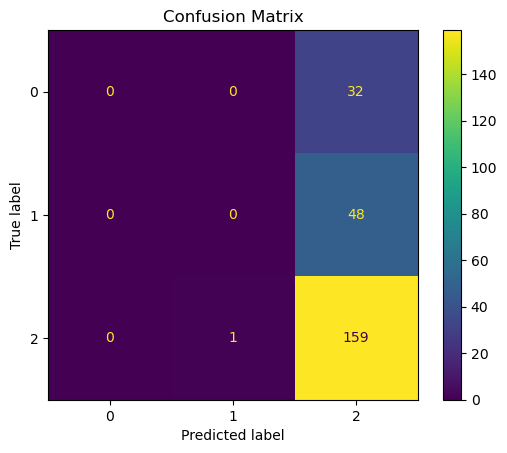

In [19]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

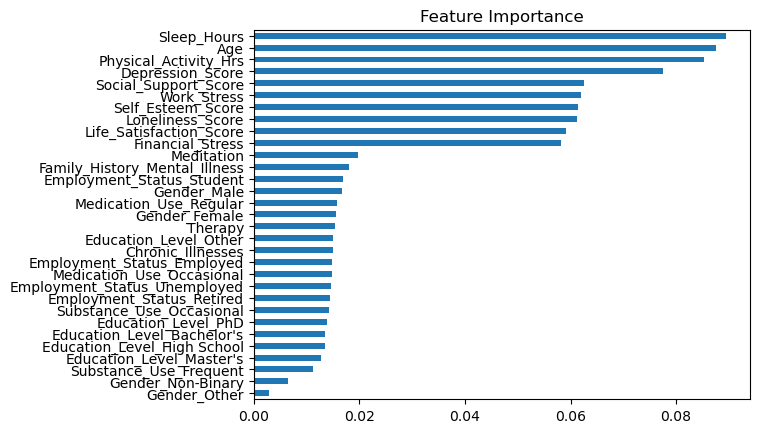

In [20]:
importance = model.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importance, index=feature_names)
feat_imp.sort_values().plot(kind='barh')

plt.title("Feature Importance")
plt.show()